# NB04b — Per-MAG Accessory Contrast (proper test of H4)

**Project**: NEON metagenome lineage novelty and functional ecology

## Why this notebook exists

NB04 used a *community-level proxy* — the union of KO content across all workflows where genus G was detected — to compare against the cultured KE pangenome accessory of G. That proxy returned a degenerate result: nearly every KO in the universe (9,547 of 9,584) was classified as "NEON-only" because community KO content is overwhelmingly dominated by co-occurring taxa, not by the target genus. No KEGG module enrichment was possible.

On re-inspection of the schema, BERDL actually *does* index a per-MAG gene mapping:

- `workflow_execution_set_mags_list.members_id` is an `array<string>` of contig IDs (one per contig in that MAG), of the form `nmdc:wfmgan-11-<workflow>_<NNNNNNN>`.
- `nmdc_results.annotation_kegg_orthology` carries `gene_id` of the form `<contig_id>_<start>_<end>`, so the join `gene_id LIKE members_id || '_%'` (or equivalently equi-join on the extracted contig portion) connects per-gene KO annotations to specific MAGs.

This notebook does the proper test: per-NEON-MAG KO set vs cultured KE pangenome accessory of the same genus. H4's falsification rule is applied to *MAGs*, not to communities.

## Hypothesis (H4) — restated for clarity

For each NEON MAG of a genus with ≥1 KE pangenome species representative:

- **H0**: The MAG's KO set is a strict subset of the cultured accessory pangenome of its genus (no novel accessory genes are detected in the field that aren't already in cultured representatives).
- **H1**: The MAG carries one or more KOs absent from any cultured accessory representative of its genus. When pooled across MAGs and genera, those *field-only* KOs are enriched for environmental-process modules (metal homeostasis, secondary metabolism, anaerobic respiration).

**Falsification rule (amended for per-MAG resolution)**: Fewer than 30% of analyzed MAGs show ≥10 field-only KOs (the count criterion was tighter for the per-MAG version since the noise floor is lower) **OR** no KEGG module is enriched in the pooled field-only KO set at FDR < 0.05.

## Outputs

- `data/04b_mag_ko_sets.tsv.gz` — per-MAG KO set (one row per MAG, semicolon-joined KOs)
- `data/04b_per_mag_contrast.tsv` — per-MAG counts: KO set size, intersection with cultured G accessory, field-only count, lab-only count, Jaccard
- `data/04b_per_genus_summary.tsv` — per-genus aggregate (fraction of MAGs with field-only KOs, recurrent field-only KOs)
- `data/04b_field_only_module_enrichment.tsv` — KEGG module enrichment on pooled field-only KOs
- `figures/04b_field_only_per_mag.png` — distribution of field-only count per MAG by genus
- `figures/04b_module_enrichment.png` — top enriched modules (if any)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

spark = get_spark_session()
DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')

## 1. Identify the analysis cohort

Same filter as NB04: NEON genera with ≥5 MQ+HQ MAGs and ≥5 pangenome species. We reuse the per-genus pangenome accessory KO sets that NB04 saved to `data/04_genus_accessory_pangenome.tsv` so we don't repeat the heavy pangenome join.

In [2]:
mags = pd.read_csv(f'{DATA_DIR}/mag_inventory.tsv', sep='\t')
for c in ['gtdbtk_domain','gtdbtk_phylum','gtdbtk_genus','gtdbtk_species']:
    mags[c] = mags[c].where(mags[c].notna() & mags[c].astype(str).str.strip().ne('null') & mags[c].astype(str).str.strip().ne(''))
good = mags[mags.bin_quality.isin(['MQ','HQ']) & mags.gtdbtk_genus.notna()].copy()

# Reuse per-genus accessory KOs from NB04
acc_tab = pd.read_csv(f'{DATA_DIR}/04_genus_accessory_pangenome.tsv', sep='\t')
acc_by_genus = {row.genus: set(row.kos.split(';')) for row in acc_tab.itertuples() if isinstance(row.kos, str)}
shared_genera = sorted(acc_by_genus.keys())
print(f'shared genera (reused from NB04): {len(shared_genera)}')
cohort = good[good.gtdbtk_genus.isin(shared_genera)].copy()
print(f'cohort MQ+HQ MAGs in those genera: {len(cohort)}')
print(cohort.gtdbtk_genus.value_counts())

shared genera (reused from NB04): 24
cohort MQ+HQ MAGs in those genera: 246
gtdbtk_genus
Mycobacterium         29
Palsa-295             23
Acidoferrum           20
Sulfotelmatobacter    20
Bradyrhizobium        16
Palsa-465             12
Rubrivivax            12
Rhizomicrobium         9
13-2-20CM-66-19        9
Palsa-1447             8
Planktothrix           8
UBA953                 7
Dolichospermum         7
Puia                   7
Terracidiphilus        7
Udaeobacter            6
UBA11358               6
Acidocella             6
Pseudolabrys           6
Ferruginibacter        6
Flavobacterium         6
Reyranella             6
Pseudonocardia         5
BOG-234                5
Name: count, dtype: int64


## 2. Per-MAG KO sets via the contig→gene→KO chain

### Join schema

```
mags_list.members_id  -- array<string> of contig IDs per MAG
         |
         | explode
         v
(mag_id, contig_id)
         |
         | equi-join on contig_id = regexp_extract(gene_id, '^(.+)_[0-9]+_[0-9]+$', 1)
         v
annotation_kegg_orthology(gene_id, annotation_id, workflow_run_id)
         |
         | parse annotation_id 'KO:K01234' -> 'K01234'
         v
per-MAG distinct KOs
```

### Scale management

`annotation_kegg_orthology` has 1.83 B rows globally. We can't full-scan it. The MAGs in our cohort come from a small set of MetagenomeAnnotation workflows (~a few hundred); we pre-restrict the table to those workflow_run_ids via an IN-filter, which Spark pushes down to predicate-partition pruning. After that pruning the table is small enough for a hash-join on contig_id.

In [3]:
# Bridge MAG workflows (wfmag-) to annotation workflows (wfmgan-) via data_generation_id
wf_inv = pd.read_csv(f'{DATA_DIR}/workflow_inventory.tsv', sep='\t')
ann_per_dg = (wf_inv[wf_inv.workflow_type == 'nmdc:MetagenomeAnnotation']
              .drop_duplicates(subset=['data_generation_id'], keep='first')
              .set_index('data_generation_id')['workflow_id'])
cohort['annot_workflow_id'] = cohort.data_generation_id.map(ann_per_dg)
cohort = cohort.dropna(subset=['annot_workflow_id'])
print('cohort MAGs with an annotation workflow:', len(cohort))
neon_ann_workflow_ids = sorted(cohort.annot_workflow_id.unique())
print('distinct annotation workflows:', len(neon_ann_workflow_ids))

cohort MAGs with an annotation workflow: 246
distinct annotation workflows: 110


In [4]:
# Stage the cohort to Spark (mag_workflow_id = wfmag- id, bin_name, genus)
cohort_pdf = cohort[['workflow_id','bin_name','gtdbtk_genus']].rename(columns={'workflow_id':'mag_workflow_id','gtdbtk_genus':'genus'})
spark.createDataFrame(cohort_pdf).createOrReplaceTempView('cohort_mags')
spark.createDataFrame(pd.DataFrame({'ann_workflow_id': neon_ann_workflow_ids})).createOrReplaceTempView('cohort_ann_workflows')

In [5]:
# Get the (mag, contig_id) pairs in Spark
mag_contigs = spark.sql("""
    SELECT cm.mag_workflow_id, cm.bin_name, cm.genus,
           explode(m.members_id) AS contig_id
    FROM cohort_mags cm
    JOIN nmdc_metadata.workflow_execution_set_mags_list m
      ON m.parent_id = cm.mag_workflow_id AND m.bin_name = cm.bin_name
""")
mag_contigs.createOrReplaceTempView('mag_contigs')
n_pairs = mag_contigs.count()
print(f'(MAG, contig) pairs: {n_pairs:,}')

(MAG, contig) pairs: 98,682


In [6]:
# Heavy join: filter annotation_kegg_orthology to NEON cohort annotation workflows,
# extract contig from gene_id, equi-join to mag_contigs.
mag_kos = spark.sql("""
    WITH ann_neon AS (
      SELECT akg.gene_id,
             regexp_extract(akg.gene_id, '^(.+)_[0-9]+_[0-9]+$', 1) AS contig_id,
             regexp_replace(akg.annotation_id, '^KO:', '') AS ko_id
      FROM nmdc_results.annotation_kegg_orthology akg
      JOIN cohort_ann_workflows w ON w.ann_workflow_id = akg.workflow_run_id
      WHERE akg.annotation_id LIKE 'KO:K%'
    )
    SELECT mc.mag_workflow_id, mc.bin_name, mc.genus, an.ko_id,
           COUNT(*) AS n_gene_hits
    FROM mag_contigs mc
    JOIN ann_neon an ON an.contig_id = mc.contig_id
    GROUP BY mc.mag_workflow_id, mc.bin_name, mc.genus, an.ko_id
""").toPandas()
print(f'(MAG × KO) rows: {len(mag_kos):,}')
print(f'distinct MAGs with KO data: {mag_kos.groupby(["mag_workflow_id","bin_name"]).ngroups}')
print(f'distinct KOs across cohort MAGs: {mag_kos.ko_id.nunique()}')

(MAG × KO) rows: 86,285
distinct MAGs with KO data: 73
distinct KOs across cohort MAGs: 4997


In [7]:
# Persist the per-MAG KO sets
mag_id = mag_kos.mag_workflow_id + '::' + mag_kos.bin_name
mag_ko_sets = mag_kos.assign(mag_id=mag_id).groupby(['mag_id','genus']).ko_id.apply(set).reset_index()
mag_ko_sets['n_kos'] = mag_ko_sets.ko_id.apply(len)
mag_ko_sets['kos'] = mag_ko_sets.ko_id.apply(lambda s: ';'.join(sorted(s)))
mag_ko_sets.drop(columns=['ko_id']).to_csv(f'{DATA_DIR}/04b_mag_ko_sets.tsv.gz', sep='\t', index=False, compression='gzip')
print('wrote 04b_mag_ko_sets.tsv.gz')
print('per-MAG KO set size distribution:')
print(mag_ko_sets.n_kos.describe().round(1))

wrote 04b_mag_ko_sets.tsv.gz
per-MAG KO set size distribution:
count      73.0
mean     1182.0
std       353.0
min       517.0
25%       944.0
50%      1113.0
75%      1392.0
max      1952.0
Name: n_kos, dtype: float64


## 3. Per-MAG field-vs-cultured contrast

For each MAG, compute set arithmetic against its genus's cultured accessory KO set:

- **intersection** = KOs in both → genuine accessory genes the lab catalog already knew about
- **field-only** = in MAG, not in cultured accessory of same genus → candidate "environmental" accessory genes
- **lab-only** = in cultured accessory, not in this MAG → genes a particular MAG doesn't carry
- **Jaccard** = intersection / union

We also flag MAGs whose KO content was too small to make a meaningful comparison (less than 200 KOs; usually means very fragmented bins).

In [8]:
# Rebuild per-MAG KO sets as a dict for arithmetic
mag_dict = {row.mag_id: (row.genus, set(row.kos.split(';'))) for _, row in mag_ko_sets.iterrows()}

rows = []
for mag_id, (g, ko_set) in mag_dict.items():
    accessory = acc_by_genus.get(g, set())
    inter = ko_set & accessory
    field_only = ko_set - accessory
    lab_only = accessory - ko_set
    union = ko_set | accessory
    rows.append({
        'mag_id': mag_id, 'genus': g,
        'mag_ko_size': len(ko_set), 'accessory_ko_size': len(accessory),
        'intersection': len(inter), 'field_only': len(field_only), 'lab_only': len(lab_only),
        'jaccard': len(inter)/max(len(union),1),
        'frac_field_only_of_mag': len(field_only)/max(len(ko_set),1),
        'usable': len(ko_set) >= 200,
    })
per_mag = pd.DataFrame(rows).sort_values(['genus','field_only'], ascending=[True, False])
per_mag.to_csv(f'{DATA_DIR}/04b_per_mag_contrast.tsv', sep='\t', index=False)
print(f'analyzed MAGs: {len(per_mag)}, usable (≥200 KOs): {per_mag.usable.sum()}')
print('\nfield_only KO count per MAG — distribution among usable:')
print(per_mag[per_mag.usable].field_only.describe().round(1))
print('\njaccard distribution among usable:')
print(per_mag[per_mag.usable].jaccard.describe().round(3))

analyzed MAGs: 73, usable (≥200 KOs): 73

field_only KO count per MAG — distribution among usable:
count     73.0
mean     342.9
std      201.3
min       46.0
25%      149.0
50%      371.0
75%      453.0
max      723.0
Name: field_only, dtype: float64

jaccard distribution among usable:
count    73.000
mean      0.416
std       0.092
min       0.237
25%       0.330
50%       0.432
75%       0.489
max       0.538
Name: jaccard, dtype: float64


In [9]:
# Per-genus aggregation
usable = per_mag[per_mag.usable]
per_genus = usable.groupby('genus').agg(
    n_mags=('mag_id','count'),
    median_mag_ko_size=('mag_ko_size','median'),
    median_field_only=('field_only','median'),
    median_jaccard=('jaccard','median'),
    frac_with_ge_10_field_only=('field_only', lambda s: (s >= 10).mean()),
).round(2).sort_values('median_field_only', ascending=False)
per_genus.to_csv(f'{DATA_DIR}/04b_per_genus_summary.tsv', sep='\t')
print(per_genus.head(25))

                    n_mags  median_mag_ko_size  median_field_only  \
genus                                                               
Planktothrix             8              1073.0              688.5   
Dolichospermum           7              1025.0              532.0   
Palsa-465                3              1222.0              502.0   
Puia                     2              1082.0              466.5   
Sulfotelmatobacter       5              1253.0              434.0   
Rubrivivax              10              1769.0              396.5   
Palsa-295                3              1046.0              384.0   
Acidoferrum              2              1240.5              372.5   
Palsa-1447               4              1219.5              370.5   
13-2-20CM-66-19          3              1509.0              340.0   
Ferruginibacter          5              1017.0              198.0   
Bradyrhizobium           2              1815.0              160.5   
Rhizomicrobium           1        

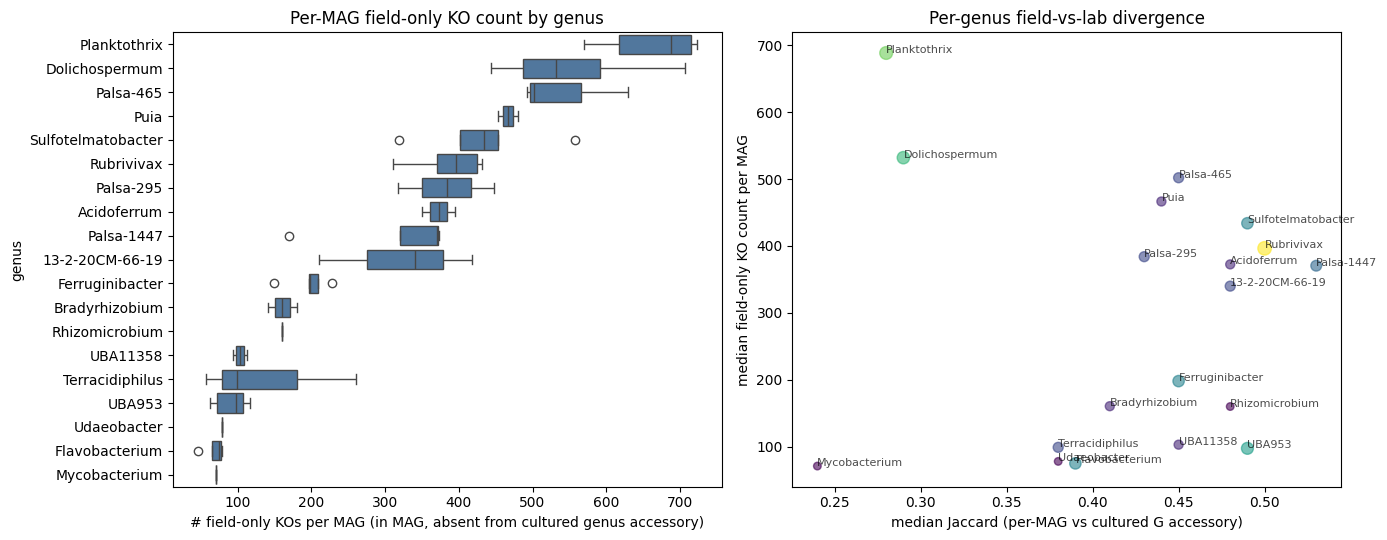

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axes[0]
sub = usable.copy()
order = per_genus.index.tolist()
sub['genus'] = pd.Categorical(sub['genus'], categories=order, ordered=True)
import seaborn as sns
sns.boxplot(data=sub, x='field_only', y='genus', ax=ax, color='#4477AA', orient='h')
ax.set_xlabel('# field-only KOs per MAG (in MAG, absent from cultured genus accessory)')
ax.set_title('Per-MAG field-only KO count by genus')

ax = axes[1]
ax.scatter(per_genus.median_jaccard, per_genus.median_field_only,
           s=np.sqrt(per_genus.n_mags) * 30, alpha=0.6, c=per_genus.n_mags, cmap='viridis')
for g, row in per_genus.iterrows():
    ax.annotate(g, (row.median_jaccard, row.median_field_only), fontsize=8, alpha=0.7)
ax.set_xlabel('median Jaccard (per-MAG vs cultured G accessory)')
ax.set_ylabel('median field-only KO count per MAG')
ax.set_title('Per-genus field-vs-lab divergence')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04b_field_only_per_mag.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Recurrent field-only KOs and KEGG module enrichment

A single field-only KO in one MAG could be noise. A KO that appears as field-only in many MAGs of the same genus is much more interesting — it suggests a systematic field-vs-lab gene-content gap. We aggregate **recurrent field-only KOs** at the genus level (KO appears as field-only in ≥ 50% of usable MAGs of that genus), then pool across genera.

The KEGG module enrichment then asks: in this *pooled* set of recurrent field-only KOs, which modules are over-represented relative to the KO universe used in NB03?

In [11]:
# Recurrent field-only KOs per genus
recurrent = {}
for g, sub in usable.groupby('genus'):
    if len(sub) < 3:
        continue
    mag_ids = sub.mag_id.tolist()
    accessory = acc_by_genus.get(g, set())
    # Count, per KO, how many MAGs of this genus have it as field-only
    ko_counts = {}
    for mid in mag_ids:
        ko_set = mag_dict[mid][1]
        for k in ko_set - accessory:
            ko_counts[k] = ko_counts.get(k, 0) + 1
    threshold = max(2, int(0.5 * len(mag_ids)))
    recurrent[g] = {k for k,v in ko_counts.items() if v >= threshold}
pooled_field_only = set().union(*recurrent.values()) if recurrent else set()
print(f'genera with ≥3 usable MAGs: {len(recurrent)}')
print(f'pooled recurrent field-only KOs (≥50% of genus MAGs): {len(pooled_field_only)}')

genera with ≥3 usable MAGs: 12
pooled recurrent field-only KOs (≥50% of genus MAGs): 2539


In [12]:
# Universe = KOs in our prevalence-filtered KO matrix from NB03 (same calibration)
M = pd.read_csv(f'{DATA_DIR}/03_ko_matrix.tsv.gz', sep='\t', index_col='workflow_id', nrows=1)
universe = set(M.columns)
ko_module = spark.sql("SELECT replace(ko_id,'ko:','') AS ko_id, module_id FROM nmdc_arkin.kegg_ko_module").toPandas()
ko_module_u = ko_module[ko_module.ko_id.isin(universe)]
print('universe KOs:', len(universe), 'with module mapping:', ko_module_u.ko_id.nunique())

rows = []
field_only_u = pooled_field_only & universe
print('pooled field-only KOs in universe:', len(field_only_u))
for mod, sub in ko_module_u.groupby('module_id'):
    mod_kos = set(sub.ko_id)
    a = len(field_only_u & mod_kos)
    b = len(field_only_u - mod_kos)
    c = len(mod_kos - field_only_u)
    d = len(universe - field_only_u - mod_kos)
    if a == 0 or a + c < 3: continue
    odds, p = stats.fisher_exact([[a, b], [c, d]], alternative='greater')
    rows.append({'module_id': mod, 'k_in_field_only': a, 'k_total_in_module': a+c,
                 'fold_enrichment': (a/max(a+b,1)) / max(((a+c)/(a+b+c+d)), 1e-9),
                 'p': p})
mod_enr = pd.DataFrame(rows)
if len(mod_enr):
    mod_enr['fdr_q'] = multipletests(mod_enr.p, method='fdr_bh')[1]
    mod_enr = mod_enr.sort_values(['fdr_q','fold_enrichment'], ascending=[True, False])
    mod_enr.to_csv(f'{DATA_DIR}/04b_field_only_module_enrichment.tsv', sep='\t', index=False)
    sig = mod_enr[mod_enr.fdr_q < 0.05]
    print(f'{len(sig)} modules enriched in pooled field-only KOs at FDR < 0.05')
    print(sig.head(25).to_string(index=False))
else:
    print('no module enrichment computed')

universe KOs: 9584 with module mapping: 1644
pooled field-only KOs in universe: 2536


29 modules enriched in pooled field-only KOs at FDR < 0.05
module_id  k_in_field_only  k_total_in_module  fold_enrichment            p        fdr_q
   M00178               52                 54         3.639210 5.082209e-28 9.503730e-26
   M00145               15                 17         3.334570 1.633399e-07 1.527228e-05
   M00163               11                 11         3.779180 4.382160e-07 2.731546e-05
   M00016               11                 12         3.464248 3.987157e-06 1.863996e-04
   M00157                8                  8         3.779180 2.383905e-05 6.368431e-04
   M00164                8                  8         3.779180 2.383905e-05 6.368431e-04
   M00026               12                 15         3.023344 2.281819e-05 6.368431e-04
   M00161               15                 23         2.464682 1.085859e-04 2.538195e-03
   M00096                8                  9         3.359271 1.642046e-04 3.411807e-03
   M00022               10                 13      

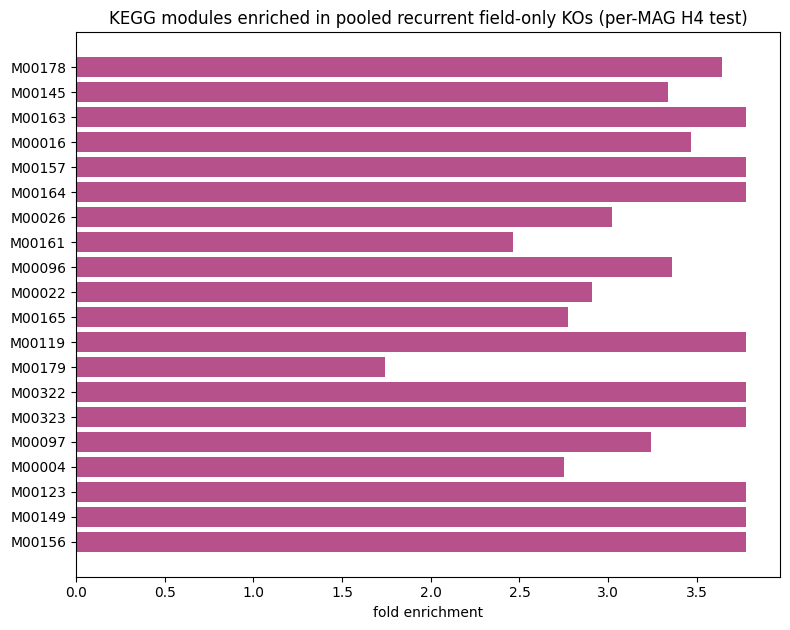

In [13]:
if len(mod_enr):
    sig = mod_enr[mod_enr.fdr_q < 0.05].head(20)
    if len(sig):
        fig, ax = plt.subplots(figsize=(8, max(3, 0.32*len(sig))))
        ax.barh(sig.module_id[::-1], sig.fold_enrichment[::-1], color='#AA3377', alpha=0.85)
        ax.set_xlabel('fold enrichment')
        ax.set_title('KEGG modules enriched in pooled recurrent field-only KOs (per-MAG H4 test)')
        plt.tight_layout()
        plt.savefig(f'{FIG_DIR}/04b_module_enrichment.png', dpi=120, bbox_inches='tight')
        plt.show()

## 5. H4 verdict (per-MAG version)

In [14]:
frac_mags_ge_10 = (per_mag[per_mag.usable].field_only >= 10).mean()
n_modules_sig = int((mod_enr.fdr_q < 0.05).sum()) if 'mod_enr' in dir() and len(mod_enr) else 0
print('H4 (per-MAG) — environmental MAGs carry KOs absent from cultured G accessory pangenomes?')
print(f'  cohort: {len(per_mag)} MAGs across {per_mag.genus.nunique()} genera')
print(f'  usable MAGs (≥200 KOs): {per_mag.usable.sum()}')
print(f'  fraction of usable MAGs with ≥10 field-only KOs: {frac_mags_ge_10:.2%}')
print(f'  modules enriched in pooled recurrent field-only KOs (FDR<0.05): {n_modules_sig}')
h4_count_pass = frac_mags_ge_10 >= 0.30
h4_direction_pass = n_modules_sig >= 1
print(f'  count criterion (≥30% of MAGs have ≥10 field-only KOs): {h4_count_pass}')
print(f'  direction criterion (≥1 KEGG module enriched): {h4_direction_pass}')
print(f'  H4 supported (both criteria): {h4_count_pass and h4_direction_pass}')

H4 (per-MAG) — environmental MAGs carry KOs absent from cultured G accessory pangenomes?
  cohort: 73 MAGs across 19 genera
  usable MAGs (≥200 KOs): 73
  fraction of usable MAGs with ≥10 field-only KOs: 100.00%
  modules enriched in pooled recurrent field-only KOs (FDR<0.05): 29
  count criterion (≥30% of MAGs have ≥10 field-only KOs): True
  direction criterion (≥1 KEGG module enriched): True
  H4 supported (both criteria): True
